# Мататематички методи за машинско учење 2025/2026
## Домаћи задатак број 4

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b> Danilo Milošević

<b>Број индекса:</b> 1732
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 04Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [50]:
import numpy as np
import scipy as sp
import numpy.random as rndm
import matplotlib as mplb
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.linalg as la

**Задатак 1.** Нека је дата матрица $A\in\mathcal{M}_{m\times n}.$ Декомпозиција пуног ранга изражава матрицу $A,$ ${\rm rang}(A)=r\leq\min\{m,n\}$ у облику производа $A=XY,$ $X\in\mathcal{M}_{m\times r},$ $Y\in\mathcal{M}_{r\times n},$ ${\rm rang}(X)={\rm rang}(Y)=r.$ 

**а)** Која од матрица $X$ и $Y$ обезбеђује базу простора врста, а која простора колона матрице $A?$ Како све можемо одредити базне векторе левог и десног језгра матрице $A?$ Због чега ортогоналне базе у овом поступку имају предност?

(5 поена)

\begin{align*}
A &= XY \\
A_{ij} &= \sum_k X_{ik}Y_{kj} \\
\\
A_{j} &= \sum_k X_{k}Y_{kj} \Rightarrow
A_{j} &= X \cdot Y_j
\end{align*}
pri čemu je $X_k$ $k$-ta kolona matrice $X$. Time možemo da zaključimo da matrica $X$ obezbeđuje bazu prostora kolona matrice A, a da su elementi $j$-te kolone matrice $Y$ koordinate date baze.

Na sličan način,
\begin{align*}
A &= XY \\
A_{ij} &= \sum_k X_{ik}Y_{kj} \\
\\
A_{i} &= \sum_k X_{ik}Y_{k} \Rightarrow
A_{i} &= X_i \cdot Y
\end{align*}
pri čemu je $Y_k$ $k$-ta vrsta matrice $Y$. Time možemo da zaključimo da matrica $Y$ obezbeđuje bazu prostora vrsta matrice A, a da su elementi $i$-te vrste matrice $X$ koordinate date baze.


**б)** Написати функцију `full_rank_decomp(A, tol=1e-10)` која рачуна `X` и `Y` факторе, али и аутоматски одређује ранг `r` матрице `A`. За декомпозицију користити `scipy.linalg.lu` која враћа `P, L, U`.
Ранг `r` одредити на основу матрице `U` и задате толеранције `tol` (број значајних пивота).
Функција треба да врати три вредности: `X`, `Y` и израчунати ранг `r`.
  
У текстуалној ћелији објаснити како се из `P, L, U` формирају `X` и `Y` и како се дефинише ранг преко матрице `U`.

**Ограничење:** Забрањено коришћење Python петљи.

(10 поена)

In [51]:
def full_rank_decomp(A, tol=1e-10):
    P, L, U = la.lu(A)
    
    diag_U = np.abs(np.diag(U))
    r = int(np.sum(diag_U > tol))
    
    X = (P @ L)[:, :r]
    Y = U[:r, :]
    
    return X, Y, r

Rang možemo dobiti kao broj nenultih elemenata na dijagonali matrice $U$. S obzirom da su moguće greške zaokruživanja bitno je proveriti koliko elemenata većih od $tol$ ima na dijagonali. Kako dobijamo matrice $P$, $L$ i $U$ možemo odrediti $X$ kao $PL$ pri čemu uzimamo $r$ kolona iz proizvoda i $Y$ kao $U$ pri čemu uzimamo prvih $r$ vrsta.

**в)** Применити написану функцију `full_rank_decomp(A)` на генерисане матрице из наредне кодне ћелије. Упоредити добијени нумерички ранг са теоријским рангом који је коришћен при генерисању. Објаснити геометријско значење ранга $r$ у контексту димензионалности података (2D и 3D).  

(5 поена)

In [52]:
bazna_matrica_r1 = np.array([[2., 1]]) # ранг 1
tezine_r1 = np.random.uniform(-10, 10, (100, 1)) 
A_r1 = tezine_r1 @ bazna_matrica_r1

bazna_matrica_r2 = np.array([[1, 0, 1],[0., 1, 1]]) # ранг 2
tezine_r2 = np.random.randn(100, 2) 
A_r2 = tezine_r2 @ bazna_matrica_r2

print(f"Матрица A_r1 генерисана: димензије {A_r1.shape}, теоријски ранг 1")
print(f"Матрица A_r2 генерисана: димензије {A_r2.shape}, теоријски ранг 2")

Матрица A_r1 генерисана: димензије (100, 2), теоријски ранг 1
Матрица A_r2 генерисана: димензије (100, 3), теоријски ранг 2


In [53]:
_, _, r1 = full_rank_decomp(A_r1)
print(f"Rang dobijen full_rank_decomp funkcijom za matricu A_r1 {r1}")
_, _, r2 = full_rank_decomp(A_r2)
print(f"Rang dobijen full_rank_decomp funkcijom za matricu A_r2 {r2}")

Rang dobijen full_rank_decomp funkcijom za matricu A_r1 1
Rang dobijen full_rank_decomp funkcijom za matricu A_r2 2


Geometrijski, rang $r$ predstavlja dimenziju slike linearne transformacije definsane matricom $A$, tj svi transformisani podaci $Ax$ leže u podprostoru dimenzije $r$.

**г)** **За матрицу `A_r1` (2D тачке):** Нацртати оригиналне тачке и правац који дефинише база простора врста.

**За матрицу `A_r2` (3D тачке):** Користећи 3D приказ, нацртати тачке и раван коју разапињу врсте матрице $A$.

Како чињеница да је $r < n$ омогућава ефикасније складиштење података? 

Израчунати број елемената потребних за чување оригиналне матрице $A$ у односу на матрице $X$ и $Y$.

(4+6+3+2 поена)

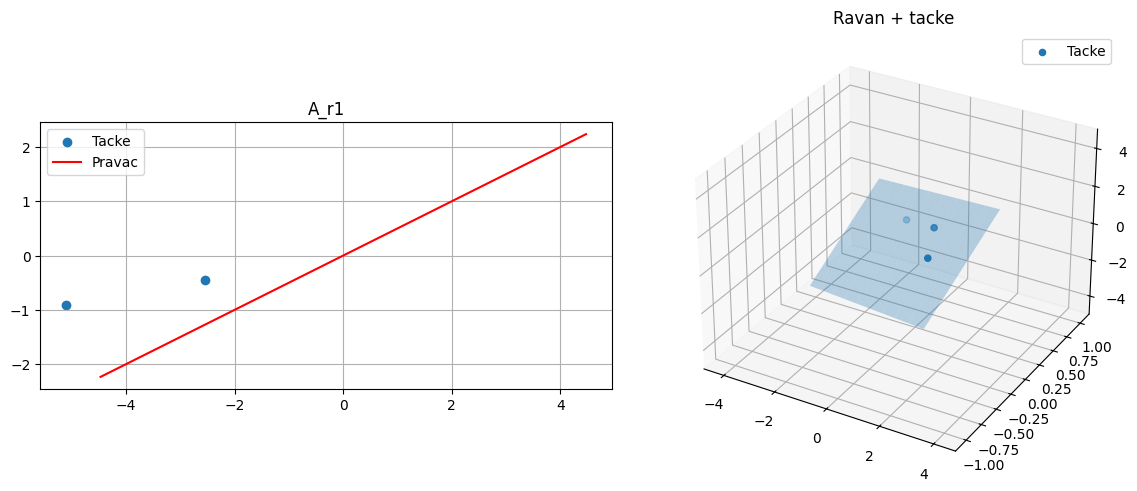


Original Ar1: 200 elemenata
X + Y: 102 elemenata (ratio 2.0x manje)

Original Ar2: 300 elemenata
X + Y: 206 elemenata (ratio 1.5x manje)


In [54]:
fig = plt.figure(figsize=(12, 5))


ax1 = fig.add_subplot(121)
_, Yf, rf1 = full_rank_decomp(A_r1)
Yf = Yf[0]
ax1.scatter(A_r1[0], A_r1[1], label='Tacke')
smer = Yf / np.linalg.norm(Yf)

t_line = np.linspace(-5, 5, 100)
ax1.plot(smer[0]*t_line, smer[1]*t_line, 'r-', label='Pravac')
ax1.set_title(f"A_r1")
ax1.legend()
ax1.grid(True)
ax1.set_aspect('equal')


ax2 = fig.add_subplot(122, projection='3d')
Xf2, _, rf2 = full_rank_decomp(A_r2)
v1 = Xf2[:, 0]
v2 = Xf2[:, 1]

s = np.linspace(-5, 5, 10)
t = np.linspace(-5, 5, 10)

X_plane = []
Y_plane = []
Z_plane = []

for si in s:
    for ti in t:
        p = si * v1 + ti * v2
        X_plane.append(p[0])
        Y_plane.append(p[1])
        Z_plane.append(p[2])

ax2.scatter(A_r2[0], A_r2[1], A_r2[2], label='Tacke')
ax2.plot_trisurf(X_plane, Y_plane, Z_plane, alpha=0.3)

ax2.set_title("Ravan + tacke")
ax2.legend()

plt.tight_layout()
plt.show()

m, n = A_r1.shape
print(f"\nOriginal Ar1: {m*n} elemenata")
print(f"X + Y: {m*rf1 + rf1*n} elemenata (ratio {m*n/(m*rf1+rf1*n):.1f}x manje)")
m, n = A_r2.shape
print(f"\nOriginal Ar2: {m*n} elemenata")
print(f"X + Y: {m*rf2 + rf2*n} elemenata (ratio {m*n/(m*rf2+rf2*n):.1f}x manje)")

Za čuvanje originalne matrice potrebno je $m * n$ elemenata dok za čuvanje dekompozicije $A = XY$ je potrebno $m*r + r*n = r*(m+n)$ elemenata. U nekim slučajevima ovo može dovesti da u ovom formatu se čuvaju više elemenata nego kod originala, ali za veće $m$ i $n$ dekompozicija dovodi do uštede memorije.

**д)** Познато је да су простор врста $\mathcal{R}(A^T)$ и језгро $\mathcal{N}(A)$ ортогонални комплементи.

Користећи функцију `scipy.linalg.null_space`, одредити базу језгра матрице $A_{r2}$. 
Програмски (скаларним производом) потврдити ортогоналност између базе простора врста и базе језгра.

Додати вектор језгра на 3D график. Прокоментарисати његов положај у односу на раван простора врста.

(10 поена)

In [55]:
null_baza = la.null_space(A_r2)
print(f"Baza jezgra A_r2: {null_baza.shape}")

Xf2, Yf2, rf2 = full_rank_decomp(A_r2)

print(np.allclose(Yf2 @ null_baza, 0))

Baza jezgra A_r2: (3, 1)
True


***

**Задатак 2.** У машинском учењу често користимо LU декомпозицију блок матрица - декомпозиција матрице на производ блок доње троугаоне и блок горње троугаоне матрице.  

Посматрајмо матрицу $ M $ подељену на блокове:
$$
M =
\begin{bmatrix}
A & B \\
C & D
\end{bmatrix},
$$
где је $ A$ квадратна регуларна матрица.

**а)** Показати (матричним множењем) да се $M$ може факторисати као:
$$M =L_BU_B=\begin{bmatrix}
I & 0 \\
CA^{-1} & I
\end{bmatrix}
\begin{bmatrix}
A & B \\
0 & S
\end{bmatrix},
$$
где је $S$ тзв. Шуров комплемент матрице $A$ у односу на $M.$

Експлицитно извести израз за $S,$
$$
S = D - CA^{-1}B.
$$

(5 поена)

Ako želimo da faktorišemo matricu M u formatu
\begin{align*}
M &=L_BU_B=\begin{bmatrix}
I & 0 \\
CA^{-1} & I
\end{bmatrix}
\begin{bmatrix}
A & B \\
0 & S
\end{bmatrix}\\
\begin{bmatrix}
A & B \\
C & D
\end{bmatrix} &= \begin{bmatrix}
I & 0 \\
CA^{-1} & I
\end{bmatrix}
\begin{bmatrix}
A & B \\
0 & S
\end{bmatrix}
\end{align*}
onda
\begin{align*}
A &= IA + 0 * 0 = A \\
B &= IB + 0 * S = B \\
C &= CAA^{-1} + I * 0 = CI = C \\
\\
D &= CA^{-1}B + IS \\
S &= D - CA^{-1}B
\end{align*}

**б)** Посматрајмо блок матрицу  
$M = \begin{bmatrix} A & B \\ C & D \end{bmatrix}$  
где је $A$ инвертибилна квадратна матрица.

Имплементирати функцију која за дату блок матрицу израчунава Шуров комплемент матрице $A$ у односу на $M.$ 

(5 поена)

In [56]:
def schurov_komplement(M, block_size):
    A = M[:block_size, :block_size]
    B = M[:block_size, block_size:]
    C = M[block_size:, :block_size]
    D = M[block_size:, block_size:]
    return D - C @ np.linalg.inv(A) @ B

size = 4
bs = size // 2

rndm.seed(7)
M_test = rndm.randn(size, size)
A_blok = M_test[:bs, :bs]

S = schurov_komplement(M_test, bs)
print(M_test)
print("Surov komplement: \n", S)


[[ 1.69052570e+00 -4.65937371e-01  3.28201637e-02  4.07516283e-01]
 [-7.88923029e-01  2.06557291e-03 -8.90385858e-04 -1.75472431e+00]
 [ 1.01765801e+00  6.00498516e-01 -6.25428974e-01 -1.71548261e-01]
 [ 5.05299374e-01 -2.61356415e-01 -2.42749079e-01 -1.45324141e+00]]
Surov komplement: 
 [[-0.5861774  -6.81658057]
 [-0.26073652 -0.6881692 ]]


**в)** Показати програмски да важи:  
$$\det(M) = \det(A)\,\det(S).$$
Применити овај концепт на блок матрицу димензија $10 \times 10$ подељену на четири блока $5 \times 5$.

(5 поена)

In [57]:
det_M = np.linalg.det(M_test)
det_AS = np.linalg.det(A_blok) * np.linalg.det(S)
print(f"det(M)        = {det_M:.6f}")
print(f"det(A)*det(S) = {det_AS:.6f}")
print(f"Razlika: {abs(det_M - det_AS):.2e}")

det(M)        = 0.500248
det(A)*det(S) = 0.500248
Razlika: 1.11e-16


**г)** Написати функцију `block_lu_step(M, block_size)` која за задату матрицу $M$ и величину горњег левог блока $A:$

- издваја блокове користећи slicing,   
- враћа матрицу $M$ трансформисану у блок горње  троугаону форму $U_B,$ као резултат блок LU процеса.  

Решење мора бити скалабилно за било коју димензију блокова.

(5 поена)

In [58]:
def block_lu_step(M, block_size):
    A = M[:block_size, :block_size]
    B = M[:block_size, block_size:]
    C = M[block_size:, :block_size]
    S = schurov_komplement(M, block_size)

    Ub = np.block([[A, B], [np.zeros_like(C), S]])
    return Ub

Ub = block_lu_step(M_test, bs)
print("Gornji levi blok = A? ", np.allclose(Ub[:bs,:bs], M_test[:bs,:bs]))
print("Donji levi blok = 0? ", np.allclose(Ub[bs:,:bs], 0))

Gornji levi blok = A?  True
Donji levi blok = 0?  True


***

**Задатак 3.** Размотримо матрицу која је нумерички "опасна" за LU декомпозицију без пивотирања:
$$ A_\varepsilon = \begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix},$$
gde je $\varepsilon < \varepsilon_{\text{mach}}.$ 

**а)** Ручно (или симболички) израчунати $L$ и $U=\begin{bmatrix}u_{00}&u_{01}\\u_{10}&u_{11}\end{bmatrix}$ факторе без пивотирања.  
Шта се дешава са елементом $u_{11}$ у аритметици са покретним зарезом? Спроведите експлицитне кораке израчунавања резултата на примеру Numpy низа $$A_\varepsilon = \begin{bmatrix} 10^{-16} & 1 \\ 1 & 1 \end{bmatrix}.$$

(10 поена)

\begin{align*}
A &= LU \\
\begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix} &= \begin{bmatrix} l_{00} & l_{01} \\ l_{10} & l_{11} \end{bmatrix} \begin{bmatrix} u_{00} & u_{01} \\ u_{10} & u_{11} \end{bmatrix}\\
l_{01} &=0, u_{10} = 0 \\
\\
\varepsilon &= l_{00}u_{00} + l_{01}u_{10} = l_{00}u_{00} \\
1 &= l_{00}u_{01} + l_{01}u_{11} =  l_{00}u_{01}\\
1 &= l_{10}u_{00} + l_{11}u_{10} =  l_{10}u_{00}\\
1 &= l_{10}u_{01} + l_{11}u_{11}\\
\end{align*}

Kako bi dobili jedinstveno rešenje, smatraćemo da je $L$ jedinična donjetrougaona matrica, tj
$$
l_{00} = 1 \\
l_{11} = 1 \\
$$
dakle

\begin{align*}
A &= LU \\
\begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix} &= \begin{bmatrix} l_{00} & l_{01} \\ l_{10} & l_{11} \end{bmatrix} \begin{bmatrix} u_{00} & u_{01} \\ u_{10} & u_{11} \end{bmatrix}\\
l_{01} &=0, u_{10} = 0 \\
l_{00} &=1, l_{11} = 1 \\
\\
\varepsilon &= u_{00} \\
1 &= u_{01}\\
1 &= l_{10}u_{00} \Rightarrow l_{10} = \dfrac{1}{\varepsilon}\\
1 &= l_{10}u_{01} + u_{11} \Rightarrow u_{11} = 1 - \dfrac{1}{\varepsilon} \\
L &= \begin{bmatrix} 1 & 0 \\ \dfrac{1}{\varepsilon} & 1 \end{bmatrix} \\
U &= \begin{bmatrix} \varepsilon & 1 \\ 0 & 1 - \dfrac{1}{\varepsilon} \end{bmatrix}
\end{align*}

In [59]:
eps = 1e-16
A_eps = np.array([[eps, 1.0],
                  [1.0, 1.0]])

L = np.eye(2)
U = A_eps.copy()
l10 = U[1, 0] / U[0, 0]
L[1, 0] = l10
U[1, :] = U[1, :] - l10 * U[0, :]

print("L:")
print(L)
print("\nU:")
print(U)
greska_rek = np.linalg.norm(A_eps - L @ U, 'fro')
print("\nRekonstrukcija:")
print(L @ U)
print("\nOriginal:")
print(A_eps)
print(f"\nGreska rekonstrukcije ||A - LU||_F = {greska_rek:.2f}")

L:
[[1.e+00 0.e+00]
 [1.e+16 1.e+00]]

U:
[[ 1.e-16  1.e+00]
 [ 0.e+00 -1.e+16]]

Rekonstrukcija:
[[1.e-16 1.e+00]
 [1.e+00 0.e+00]]

Original:
[[1.e-16 1.e+00]
 [1.e+00 1.e+00]]

Greska rekonstrukcije ||A - LU||_F = 1.00


Vrednost elementa $u_{11}$ bi trebala da bude $1 - \dfrac{1}{\varepsilon}$ ali usled nepreciznosti kod zaokruživanja dobijamo vrednost $-\dfrac{1}{\varepsilon}$

**б)** Користећи `scipy.linalg.lu`, израчунати факторе са пивотирањем.  
Упоредити грешку репродукције $\|A - PLU\|_F$ за овај и претходни поступак. Објаснити зашто је замена редова (пивотирање) неопходна за стабилност код матрица са малим елементима на главној дијагонали. 

(10 поена) 

In [60]:
eps = 1e-16
A_eps = np.array([[eps, 1.0],
                  [1.0, 1.0]])
P, L, U = la.lu(A_eps)

print("P:")
print(P)
print("\nL:")
print(L)
print("\nU:")
print(U)
greska_sa_pivot = np.linalg.norm(A_eps - P @ L @ U, 'fro')
print(f"\nGreska sa pivotiranjem  ||A - PLU||_F = {greska_sa_pivot:.2f}")

P:
[[0. 1.]
 [1. 0.]]

L:
[[1.e+00 0.e+00]
 [1.e-16 1.e+00]]

U:
[[1. 1.]
 [0. 1.]]

Greska sa pivotiranjem  ||A - PLU||_F = 0.00


Kako smo videli, mali pivot $u_{00} = \varepsilon$ uzrokuje $l10= \dfrac{1}{\varepsilon}$, što dovodi do
greške kod zaokruživanja $u_{11}$​. Zamenom redosleda vrsta tako da je pivot ($u_{00}$) najveći element u koloni, time održavajući numeričku stabilnost.

**в)** У Numpy-у, за $\varepsilon = 10^{-20},$ решити систем  
$$
A_\varepsilon x = [1, 2]^T 
$$  
на два начина:  
- Користећи сопствену имплементацију експлицитних корака без пивотирања.  
- Користећи `scipy.linalg.solve` (која користи пивотирање).

(10 поена)

Bez pivotiranja možemo rešiti na sledeći način

\begin{align*}
A_\varepsilon x &= [1, 2]^T\\
LUx &= [1, 2]^T \\
Ux &= y\\
\\
Ly &= [1, 2]^T\\
\begin{bmatrix} 1 & 0 \\ l_{10} & 1 \end{bmatrix} \begin{bmatrix} y_0\\ y_1\end{bmatrix} &= [1, 2]^T\\
\Rightarrow\\
y_0 &= 1\\
l_{10}y_0 + y_1 &= 2 \Rightarrow y_1 = 2 - l_{10}y_0\\
\\
\begin{bmatrix} u_{00} & 1 \\ 0 & u_{11} \end{bmatrix} \begin{bmatrix} x_0\\ x_1\end{bmatrix} &= \begin{bmatrix} y_0\\  y_1\end{bmatrix}\\
\\
u_{00} x_0 + x_1 &= y_0\\
u_{11} x_1 &= y_1 \\
\end{align*}

Zbog ogromnih vrednosti $l_{10} = \dfrac{1}{\varepsilon}$ i greške zaokruživanja kod $1 - \dfrac{1}{\varepsilon}$ očekujemo numerički netačan rezultat.

Ako analitički rešimo jednačinu

\begin{align*}
\begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix} \begin{bmatrix} x_0 \\ x_1 \end{bmatrix} &= [1, 2]^T\\
\\
\varepsilon x_0 + x_1 &= 1 \Rightarrow x_0 = \dfrac{1 - x_1}{\varepsilon}\\
x_0 + x_1 &= 2 \Rightarrow x_0 = 2 - x_1 \\
\\
2 - x_1 &= \dfrac{1 - x_1}{\varepsilon}\\
2\varepsilon - \varepsilon x_1 &= 1 - x_1\\
\varepsilon x_1 - x_1 &= 2\varepsilon - 1 \\
x_1 &= \boxed{\dfrac{2\varepsilon - 1}{\varepsilon - 1}}
\end{align*}

Kada $\varepsilon \rightarrow 0$
$$
x_1 \rightarrow 1 \\
x_0 \rightarrow 1
$$

In [61]:
eps = 1e-20
A_eps = np.array([[eps, 1.0], [1.0, 1.0]])
b = np.array([1.0, 2.0])

In [62]:
L = np.eye(2)
U = A_eps.copy()
l10 = U[1,0] / U[0,0]
L[1,0] = l10
U[1,:] = U[1,:] - l10 * U[0,:]

y = np.zeros(2)
y[0] = b[0]
y[1] = b[1] - L[1,0] * y[0]

x = np.zeros(2)
x[1] = y[1] / U[1,1]
x[0] = (y[0] - x[1]) / U[0,0]

x_n = x.copy()
print("Resenje bez pivotiranja:")
print(x)

Resenje bez pivotiranja:
[0. 1.]


In [63]:
x = la.solve(A_eps, b)
print("\nResenje sa pivotiranjem:")
print(x)


Resenje sa pivotiranjem:
[1. 1.]


**г)** Упоредити релативну грешку  
$$\|A x_{\text{izračunato}} - b\|.$$
Повезати резултат са задатком о катастрофалном поништавању са претходног домаћег.  

(5 поена)

In [64]:
rez_bez = np.linalg.norm(A_eps @ x_n - b)
rez_sa  = np.linalg.norm(A_eps @ x  - b)
print(f"Greska kod postupka bez pivotiranja = {rez_bez:.2f}")
print(f"Greska kod postupka sa pivotiranjem = {rez_sa:.2f}")

Greska kod postupka bez pivotiranja = 1.00
Greska kod postupka sa pivotiranjem = 0.00


***

**Задатак 4.**
У пракси се често сусрећемо са матрицама које су регуларне, али су осетљиве – мале промене у подацима доводе до огромних грешака у решењу. 

**а)** Користећи функцију `np.vander`, креирати Вандермондову матрицу $V$ димензија $10 \times 10$ над низом од 10 еквидистантних тачака из интервала $[1, 2]$. 
1. Извршити LU декомпозицију $PV = LU$. Приказати дијагоналне елементе (пивоте) матрице $U$. Шта примећујете код последњих неколико пивота?
2. Дефинисати тачно решење $x_{true} = \text{np.ones}(10)$ и израчунати десну страну $b = V x_{true}$.
3. Решити систем $Vx = b$ помоћу `np.linalg.solve`. Израчунати Фробенијусову норму грешке $\|x - x_{true}\|_F$.

(5 поена)

In [65]:
n = 10
tacke = np.linspace(1, 2, n)
V = np.vander(tacke)

P, L, U = la.lu(V)
pivoti = np.diag(U)
print("Dijagonalni elementi (pivoti) matrice U:")
for i, p in enumerate(pivoti):
    print(f"  u[{i},{i}] = {p:.2e}")

Dijagonalni elementi (pivoti) matrice U:
  u[0,0] = 5.12e+02
  u[1,1] = 1.11e+01
  u[2,2] = 6.83e-01
  u[3,3] = 7.24e-02
  u[4,4] = -1.80e-02
  u[5,5] = 3.17e-03
  u[6,6] = -3.15e-04
  u[7,7] = 4.69e-05
  u[8,8] = -2.72e-06
  u[9,9] = -3.26e-07


Primećujemo da pivoti postaju sve manji i manji, poslednjih nekoliko pivota su reda veličine $10^{-7}$.

In [66]:
x_true = np.ones(n)
b = V @ x_true
b

array([  10.        ,   16.81174792,   28.97451327,   50.2731799 ,
         86.709216  ,  147.52336476,  246.57257532,  404.14738526,
        649.32907951, 1023.        ])

In [67]:
x = np.linalg.solve(V, b)
greska = np.linalg.norm(x - x_true)
print(f"\nNorma greske ||x - x_true|| = {greska:.2e}")



Norma greske ||x - x_true|| = 4.21e-06


**б)** Симулирајмо малу грешку у мерењу података (шум). 
1. Креирати вектор слободних чланова са додатком белог шума $b_{noise} = b + \epsilon$, где је $\epsilon$ насумичан вектор јако мале норме (нпр. $10^{-8}$).
2. Поново решити систем $Vx_{noise} = b_{noise}$ и израчунати грешку $\|x_{noise} - x_{true}\|_F$.
3. Упоредити норму шума $\|\epsilon\|_F$ и норму грешке у решењу. Колико пута се грешка увећала?

(10 поена)

In [68]:
eps = np.random.randn(n) * 1e-8
b_noise = b + eps

x_noise = np.linalg.solve(V, b_noise)
greska_noise = np.linalg.norm(x_noise - x_true)
norma_suma = np.linalg.norm(eps)

print(f"Norma suma = {norma_suma:.2e}")
print(f"Greska resenja sa sumom = {greska_noise:.2e}")
print(f"Uvecanje greske = {greska_noise / norma_suma:.2e} puta")

Norma suma = 3.44e-08
Greska resenja sa sumom = 4.03e+00
Uvecanje greske = 1.17e+08 puta


**в)** Уводимо регуларизовану матрицу $V_{\lambda} = V + \lambda I.$
1. Написати функцију која за низ вредности $\lambda = [10^{-1}, 10^{-3}, 10^{-6}, 10^{-9}, 0]$ израчунава LU декомпозицију и решава систем са шумом $(V + \lambda I)x_{\lambda} = b_{noise}$.
2. За свако $\lambda$ израчунати:
   - Вредност најмањег пивота матрице $U$ (по апсолутној вредности).
   - Грешку решења $\|x_{\lambda} - x_{true}\|_F$.
3. Нацртати два графика (у логаритамској скали): 
   - Зависност најмањег пивота од $\lambda$.
   - Зависност грешке решења од $\lambda$.
   
(10 поена)

Lambda, MinPivot, Greska
1.0000e-01  1.3692e-01  8.9637e-02
1.0000e-03  3.5231e-03  9.8917e-04
1.0000e-06  2.3669e-05  2.2575e-02
1.0000e-09  2.2451e-07  5.9633e+00
0.0000e+00  3.2647e-07  4.0306e+00


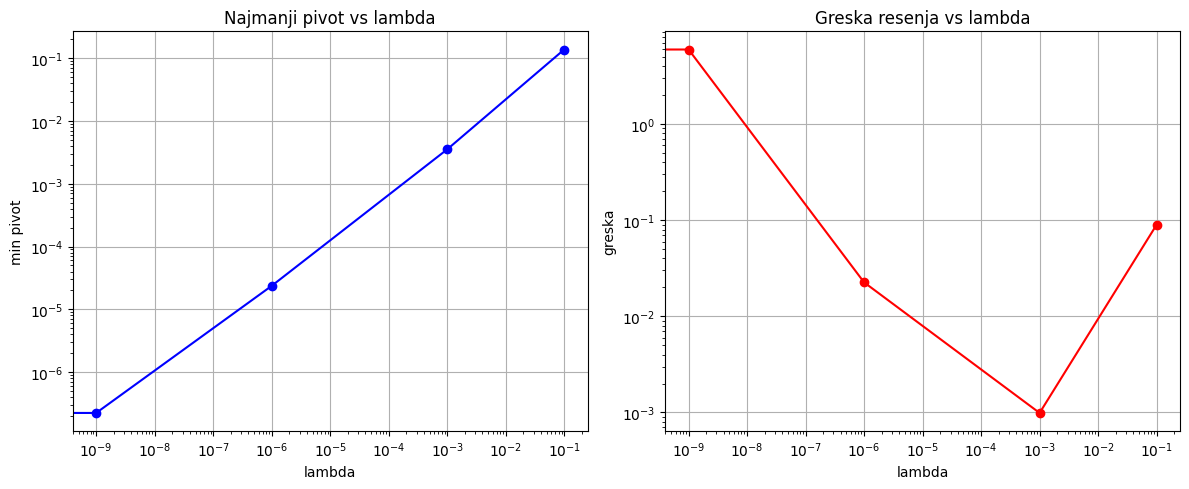

In [69]:
def lu_solution(V, b_noise, x_true, n, lm = [1e-1, 1e-3, 1e-6, 1e-9, 0.0]):

    min_pivoti = []
    greske = []

    for l in lm:
        V_l = V + l * np.eye(n)
        _, _, U_l = la.lu(V_l)

        min_piv = np.min(np.abs(np.diag(U_l)))
        x_l = np.linalg.solve(V_l, b_noise)
        g = np.linalg.norm(x_l - x_true)

        min_pivoti.append(min_piv)
        greske.append(g)

    return list(zip(lm, min_pivoti, greske))

sol = lu_solution(V, b_noise, x_true, n)

print('Lambda, MinPivot, Greska')
for l, mp, g in sol:
    print(f"{l:.4e}  {mp:.4e}  {g:.4e}")

lm = [x[0] for x in sol]
mp = [x[1] for x in sol]
err = [x[2] for x in sol]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.loglog(lm, mp, 'bo-')
ax1.set_xlabel('lambda')
ax1.set_ylabel('min pivot')
ax1.set_title('Najmanji pivot vs lambda')
ax1.grid(True)

ax2.loglog(lm, err, 'ro-')
ax2.set_xlabel('lambda')
ax2.set_ylabel('greska')
ax2.set_title('Greska resenja vs lambda')
ax2.grid(True)
plt.tight_layout()
plt.show()


**г)**  
На основу добијених графика објаснити шта се дешава са стабилношћу система када је $\lambda=0$. Како додавање малог $\lambda$ утиче на вредност пивота и зашто то спречава експлозију грешке? Повезати ово са стабилизацијом нумеричких израчунавања кроз спречавање дељења јако малим бројевима.

(5 поена)

Bez dodavanja $\lambda$ ($\lambda = 0$) dobijamo veoma male vrednosti pivota koji se kasnije koristi za računanje ostalih elemenata u $L$ i $U$ matricama. Kao što smo videli u prethodnim koracima to može izazvati eksploziju greške, s obzirom da delimo pivotom.

Dodavanjem male vrednosti $\lambda$ dijagonalnim elementima obezbeđujemo da na dijagonali nemamo veoma male vrednosti.. Ukoliko dodamo previše šuma možemo uvesti greške, s obzirom da će se matrica tada previše razlikovati od originalne. Po grafikonu možemo videti da je najbolje dodati $\lambda$ oko $10^{-2}$ do $10^{-3}$.

***

**Задатак 5.** У претходном домаћем сте користили K-means за компресију слике. Сада ћемо то упоредити са апроксимацијом ниског ранга која се ослања на декомпозицију пуног ранга матрице слике.

Активирати доњи код којим се учитава слика (grayscale) као матрица $A.$  
И дефинише функција којом се израчунава најбоља апроксимација помоћу декомпозиције пуног ранга $A_k = X_k Y_k$ на основу задатог параметра $k.$ Параметар $k$ је унапред дефинисан ранг матрица фактора $X_k$ и $Y_k.$

In [70]:
import scipy.datasets as scd

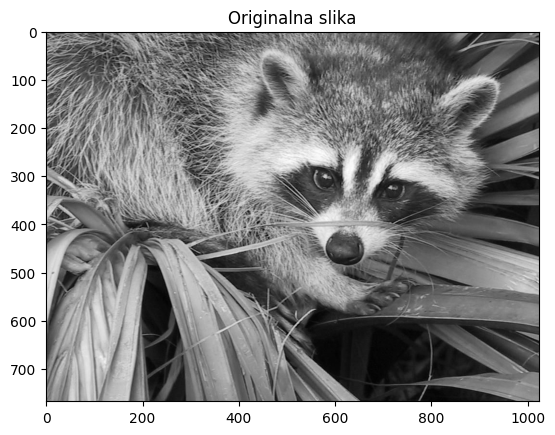

In [71]:
rakun=scd.face()
sk_vredn=rakun/255
A = sk_vredn @ [0.2126, 0.7152, 0.0722]
A.shape
plt.imshow(A, cmap="gray");
plt.title("Originalna slika");

In [72]:
def naj_aproks(A,k):
    X,S,Y=sp.linalg.svd(A)
    A_k=(X*S)[:,:k]@Y[:k,:] #деккомпозиција пуног ранга апроксимационе матрице A_k
    return(A_k)

**а)** Нацртати график зависности грешке апроксимације  
$$
\|A - A_k\|_F
$$  
од ранга $k$ (за $k\in\{1, 5, 10, 20, 50\}$).  

(5 поена)

k = 1, Greska = 169.4820
k = 5, Greska = 116.1612
k = 10, Greska = 94.3458
k = 20, Greska = 76.5816
k = 50, Greska = 55.3724


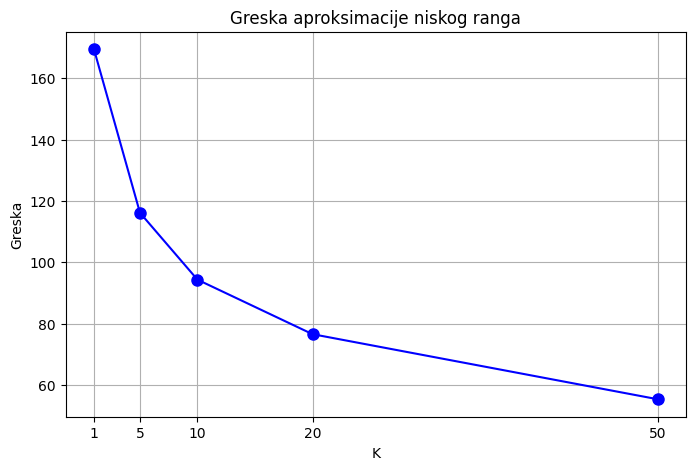

In [73]:
k_range = [1, 5, 10, 20, 50]
greske = []

for k in k_range:
    A_k = naj_aproks(A, k)
    g = np.linalg.norm(A - A_k, 'fro')
    greske.append(g)
    print(f'k = {k}, Greska = {g:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(k_range, greske, 'bo-', markersize=8)
plt.xlabel('K')
plt.ylabel('Greska')
plt.title('Greska aproksimacije niskog ranga')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**б)** Упоредити број параметара потребан за чување слике код:
- K-means сегментације (из прошлог домаћег),
- Апроксимације ниског ранга $A_k=X_k Y_k.$

Који метод боље чува текстуру, а који регије (боје)?  Можете да проверите резултате функционисања оба поступка на додатним сликама према свом избору. Бирајте неке које су природнијег садржаја наспрам слика са једним објектом у фокусу.

(10 поена)

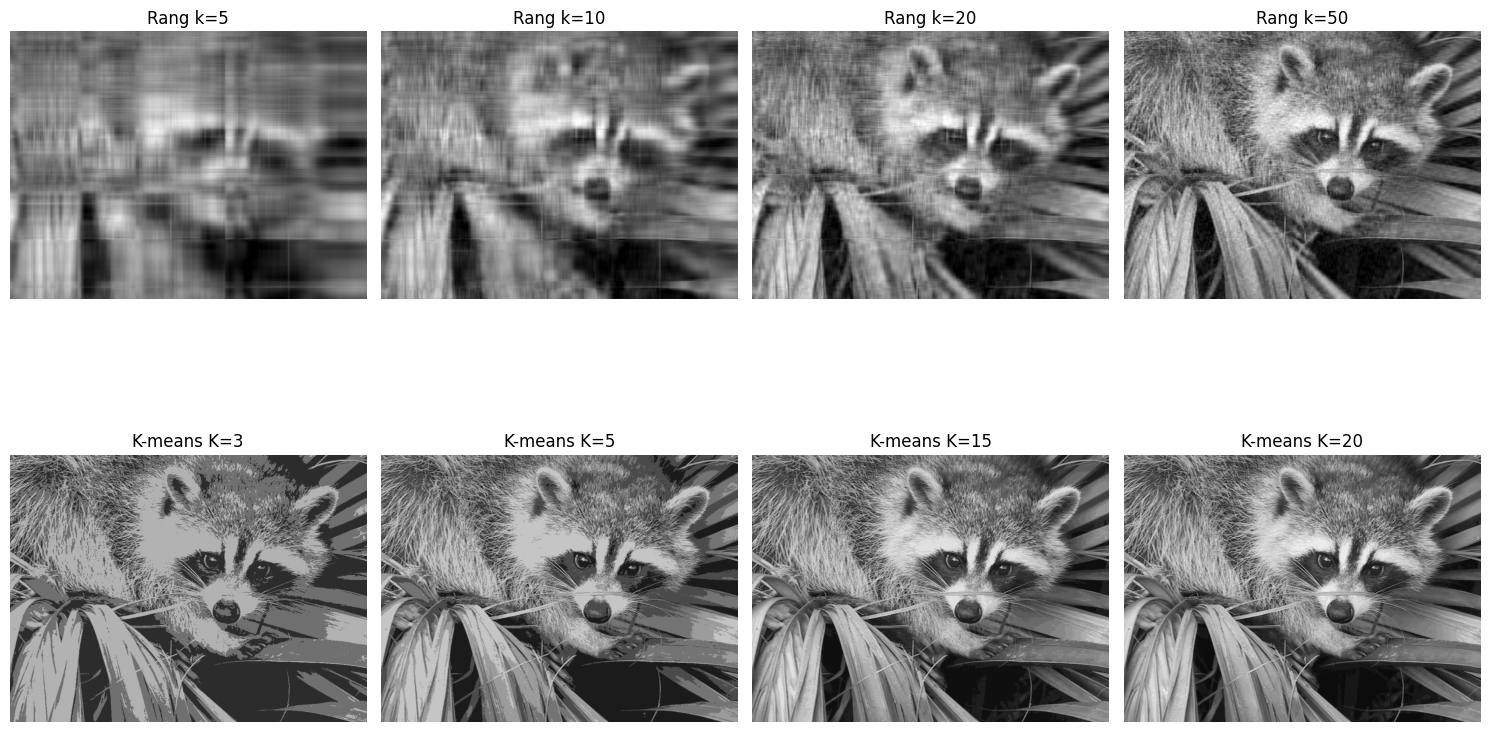

In [74]:

from sklearn.cluster import KMeans
def compare_methods(A):
    K_range = [5, 10, 20, 50]
    N_clusters = [3, 5, 15, 20]
    examples = 4

    fig, axes = plt.subplots(2, examples, figsize=(15, 10))
    axes[0,0].imshow(A, cmap='gray', vmin=0, vmax=1)
    axes[0,0].set_title('Originalna slika'); axes[0,0].axis('off')

    for idx, k in enumerate(K_range):
        A_k = np.clip(naj_aproks(A, k), 0, 1)
        axes[0,idx].imshow(A_k, cmap='gray', vmin=0, vmax=1)
        axes[0,idx].set_title(f'Rang k={k}')
        axes[0,idx].axis('off')

    A_flat = A.reshape(-1, 1)
    for idx, K in enumerate(N_clusters):
        km = KMeans(n_clusters=K, random_state=0, n_init=5)
        labele = km.fit_predict(A_flat)
        A_km = km.cluster_centers_[labele].reshape(A.shape)
        axes[1, idx].imshow(A_km, cmap='gray', vmin=0, vmax=1)
        axes[1, idx].set_title(f'K-means K={K}')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()
compare_methods(A)


Na datom primeru slike rakuna, K-Means algoritam bolje održava teksturu i strukture na slici. Čak i sa samo 3 klastera je oblik na slici jasan, dok se regije/boje gube (gore se vide senke na lišću, boja krzna itd.)

Aproksimacija niskog ranga bolje održava regije/boje, međutim se dosta gubi tekstura i oblici i tek je oblik prepoznatljiv za $K=20$ ili $K=50$.

To možemo videti i na primeru ispod sa kompleksnijom scenom.

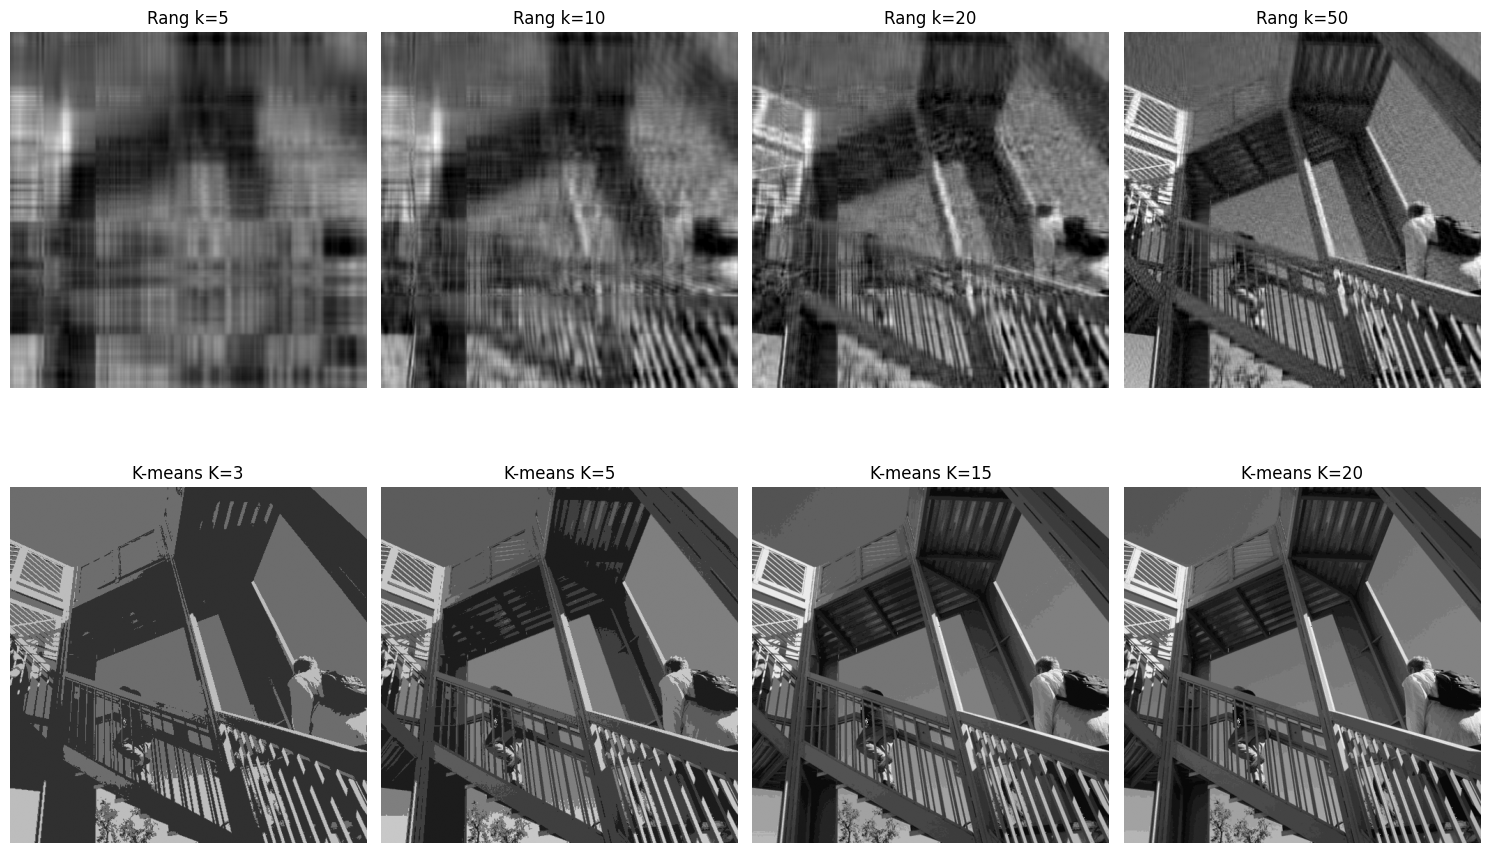

In [75]:
compare_methods((scd.ascent()/255))

***

**Задатак 6.** У обради слика, суперпиксели представљају групе пиксела које замењују класичну правоугаону мрежу. Овде ћемо слику посматрати као велику блок матрицу и спровести основну суперпиксел декомпозицију користећи векторизацију.

**а)** 
Написати функцију `image_to_blocks(img, k)` која трансформише grayscale слику димензија $H \times W$ у 4D низ димензија $(H/k, W/k, k, k)$, где сваки елемент $(i, j)$ представља блок величине $k \times k$. Такође, написати инверзну функцију `blocks_to_image(blocks)` која враћа блокове у оригинални 2D формат користећи `np.block` или паметно препакивање. 

(Напомена: Користити слику ракуна и исећи је тако да су димензије дељиве са $k=10$.)  

(10 поена)

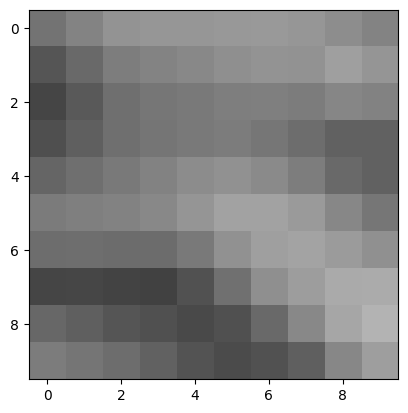

In [76]:
def image_to_blocks(img, k):
    H, W = img.shape
    nH, nW = H // k, W // k
    blocks = img.reshape(nH, k, nW, k).transpose(0, 2, 1, 3)
    return blocks

def blocks_to_image(blocks):
    nH, nW, k, _ = blocks.shape
    img = blocks.transpose(0, 2, 1, 3).reshape(nH*k, nW*k)
    return img

k = 10
H, W = A.shape
H_cut = (H // k) * k
W_cut = (W // k) * k
img = A[:H_cut, :W_cut]

blocks = image_to_blocks(img, k)
img_rek = blocks_to_image(blocks)

plt.imshow(blocks[0, 0], cmap='gray', vmin=0, vmax=1)


**б)**  За сваки блок израчунати средњи интензитет пиксела и $(x, y)$ координате центра блока у оригиналној слици. Резултат треба да буде матрица карактеристика $F$ димензија $(N_{blocks} \times 3)$. Све прорачуне извршити векторизовано (користећи `np.mean` по одговарајућим осама).  

(10 поена)

In [77]:
def blocks_to_features(blocks, k):
    nH, nW, _, _ = blocks.shape

    means = np.mean(blocks, axis=(2, 3))

    means_min = means.min()
    means_max = means.max()
    means_norm = (means - means_min) / (means_max - means_min + 1e-8)

    x_coords = (np.arange(nW) + 0.5) / nW
    y_coords = (np.arange(nH) + 0.5) / nH

    X, Y = np.meshgrid(x_coords, y_coords)

    means_flat = means_norm.reshape(-1)
    X_flat = X.reshape(-1)
    Y_flat = Y.reshape(-1)

    F = np.stack([means_flat, X_flat, Y_flat], axis=1)

    return F

F = blocks_to_features(blocks, k)
F

array([[0.48692173, 0.00490196, 0.00657895],
       [0.37350205, 0.01470588, 0.00657895],
       [0.38602115, 0.0245098 , 0.00657895],
       ...,
       [0.5781653 , 0.9754902 , 0.99342105],
       [0.56401223, 0.98529412, 0.99342105],
       [0.55733288, 0.99509804, 0.99342105]], shape=(7752, 3))

**в)**  Применити K-means кластеризацију над матрицом $F$. Реконструисати слику тако што ће сваки блок бити замењен средњим интензитетом који дефинише центар припадајућег кластера. Приказати резултат сегментације.  

(10 поена)

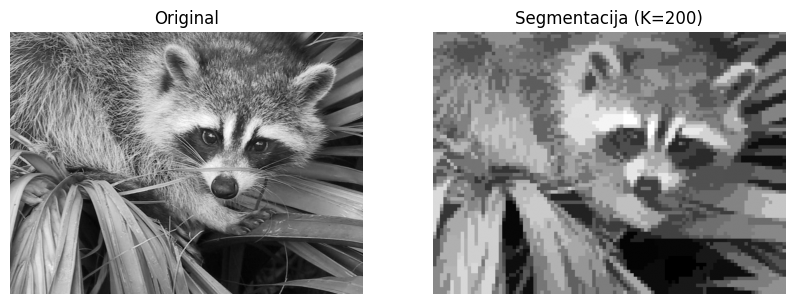

In [78]:
def segment_blocks_kmeans(blocks, F, k, K=5):
    nH, nW, _, _ = blocks.shape

    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = kmeans.fit_predict(F)
    centroids = kmeans.cluster_centers_
    cluster_means = centroids[:, 0]

    labels_2d = labels.reshape(nH, nW)
    segmented_blocks = cluster_means[labels_2d]

    segmented_img = np.repeat(np.repeat(segmented_blocks, k, axis=0), k, axis=1)

    return segmented_img

K = 200
segmented_img = segment_blocks_kmeans(blocks, F, k, K)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmentacija (K={K})")
plt.imshow(segmented_img, cmap='gray')
plt.axis('off')

plt.show()

***